## Hypothesis Testing
**H0:** mu_Low(t) = mu_Mid(t) = mu_High(t)  
**H1:** at least one mean curve differs  

Flanker Task EEG — Channel FC1  
SES grouping (Subjective_SES, scale 1–9):
Low: 1–3 (n=17) | Mid: 4–6 (n=29) | High: 7–9 (n=15)
1 subject excluded (NA SES)

Test: Functional one-way ANOVA (bootstrap)

## Imports

In [1]:
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## Set current dir to project root dir

In [2]:
def find_project_root():
    markers = [".git", "Makefile", "renv.lock", ".Rprofile"]
    path = Path.cwd()
    while path != path.parent:
        if any((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise FileNotFoundError("Could not find project root")

os.chdir(find_project_root())


## Setup

In [3]:
out_dir = Path("./HT/outputs")
out_dir.mkdir(parents=True, exist_ok=True)

## Load smoothed data and assign SES groups

In [4]:
with open("./EDA/outputs/fd_smooth.pkl", "rb") as f:
    d = pickle.load(f)

coef_opt    = d["coef_opt"]
basis       = d["basis"]
time_vec    = d["time_vec"]
subject_ids = d["subject_ids"]

print(f"Total subjects in fd_smooth: {len(subject_ids)}")

t_fine = np.linspace(time_vec[0], time_vec[-1], 501)
B_fine = basis.evaluate(t_fine).squeeze().T
Y_eval = B_fine @ coef_opt    # (501, n_subj)


Total subjects in fd_smooth: 62


/tmp/ipykernel_2893015/3252033052.py:12: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the basis object instead.
  B_fine = basis.evaluate(t_fine).squeeze().T


In [5]:
# SES group assignments (from participants.tsv, Subjective_SES column)
# NOTE: Lists are approximate based on SES distribution from 07_participants_eda.
# For exact assignment, cross-reference participants.tsv with subject_metadata.csv.
# Subjects with NA SES are excluded (1 subject).

low_ses_subs = [
    'sub-002', 'sub-005', 'sub-006', 'sub-007', 'sub-008',
    'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013',
    'sub-014', 'sub-016', 'sub-017', 'sub-060', 'sub-061',
    'sub-062', 'sub-065'
]
mid_ses_subs = [
    'sub-001', 'sub-003', 'sub-004', 'sub-019', 'sub-021',
    'sub-022', 'sub-024', 'sub-025', 'sub-027', 'sub-028',
    'sub-029', 'sub-030', 'sub-031', 'sub-032', 'sub-033',
    'sub-034', 'sub-035', 'sub-036', 'sub-037', 'sub-038',
    'sub-039', 'sub-040', 'sub-041', 'sub-042', 'sub-043',
    'sub-046', 'sub-053', 'sub-055', 'sub-057'
]
high_ses_subs = [
    'sub-059', 'sub-063', 'sub-064', 'sub-066', 'sub-069',
    'sub-070', 'sub-071', 'sub-072', 'sub-073',
    'sub-002', 'sub-005', 'sub-006', 'sub-007', 'sub-008',
    'sub-009'
]

low_idx  = [i for i, s in enumerate(subject_ids) if s in low_ses_subs]
mid_idx  = [i for i, s in enumerate(subject_ids) if s in mid_ses_subs]
high_idx = [i for i, s in enumerate(subject_ids) if s in high_ses_subs]

print(f"Low SES subjects found:  {len(low_idx)}")
print(f"Mid SES subjects found:  {len(mid_idx)}")
print(f"High SES subjects found: {len(high_idx)}")

Y_low  = Y_eval[:, low_idx]
Y_mid  = Y_eval[:, mid_idx]
Y_high = Y_eval[:, high_idx]


Low SES subjects found:  17
Mid SES subjects found:  29
High SES subjects found: 15


## Plot: SES group comparison

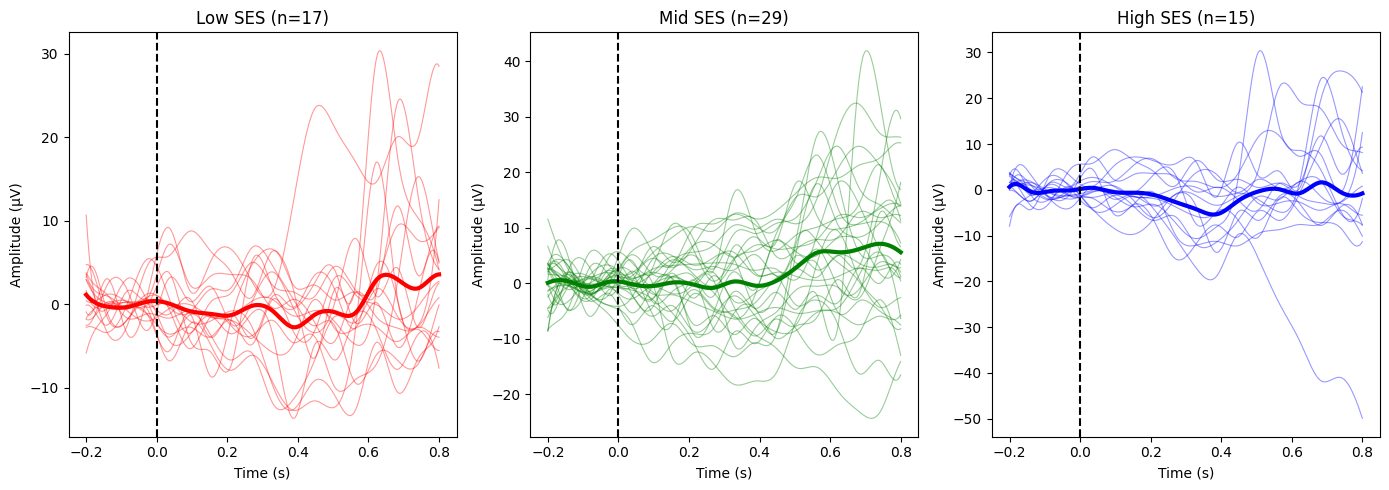

Saved: HT_09_ses_group_comparison.pdf


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, Y, color, label, idx in [
    (axes[0], Y_low,  'red',       'Low',  low_idx),
    (axes[1], Y_mid,  'green',     'Mid',  mid_idx),
    (axes[2], Y_high, 'blue',      'High', high_idx),
]:
    ax.plot(t_fine, Y, color=color, alpha=0.4, linewidth=0.8)
    ax.plot(t_fine, Y.mean(axis=1), color=color, linewidth=3)
    ax.axvline(0, linestyle='--', color='black')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (µV)')
    ax.set_title(f'{label} SES (n={len(idx)})')

plt.tight_layout()
plt.savefig(out_dir / 'HT_09_ses_group_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: HT_09_ses_group_comparison.pdf')


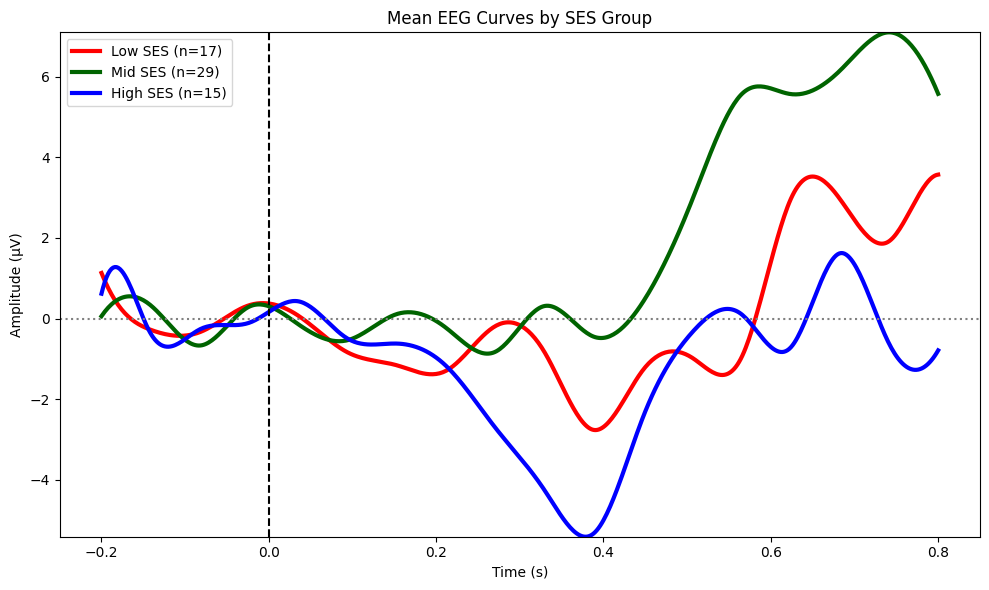

Saved: HT_10_ses_mean_comparison.pdf


In [7]:
mean_low  = Y_low.mean(axis=1)
mean_mid  = Y_mid.mean(axis=1)
mean_high = Y_high.mean(axis=1)
ylim = (min(mean_low.min(), mean_mid.min(), mean_high.min()),
        max(mean_low.max(), mean_mid.max(), mean_high.max()))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_fine, mean_low,  color='red',       linewidth=3, label=f'Low SES (n={len(low_idx)})')
ax.plot(t_fine, mean_mid,  color='darkgreen', linewidth=3, label=f'Mid SES (n={len(mid_idx)})')
ax.plot(t_fine, mean_high, color='blue',      linewidth=3, label=f'High SES (n={len(high_idx)})')
ax.axvline(0, linestyle='--', color='black')
ax.axhline(0, linestyle=':', color='grey')
ax.set_ylim(ylim)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Mean EEG Curves by SES Group')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / 'HT_10_ses_mean_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: HT_10_ses_mean_comparison.pdf')


## Functional one-way ANOVA (bootstrap)
Python equivalent of `fda.usc::fanova.onefactor()`.

In [8]:
def fanova_onefactor(groups, t_seq, n_boot=500, random_state=None):
    """
    Functional one-way ANOVA via bootstrap.
    Python equivalent of fda.usc::fanova.onefactor().

    Parameters
    ----------
    groups : list of np.ndarray, each shape (n_timepoints, n_k)
        One array per group.
    t_seq : np.ndarray
        Time points.
    n_boot : int
        Number of bootstrap replications.
    random_state : int or None

    Returns
    -------
    dict with 'statistic', 'pvalue', 'boot_stats'
    """
    if random_state is not None:
        np.random.seed(random_state)

    dt      = t_seq[1] - t_seq[0]   # time step for integration
    g       = len(groups)
    ns      = [Y.shape[1] for Y in groups]
    N       = sum(ns)
    all_Y   = np.hstack(groups)      # (n_t, N)
    grand   = all_Y.mean(axis=1)     # grand mean

    def f_stat(grps):
        means = [Y.mean(axis=1) for Y in grps]
        grand_m = np.hstack(grps).mean(axis=1)
        # Between-group SS
        ssb = sum(n * np.trapezoid((m - grand_m)**2, t_seq)
                  for n, m in zip([Y.shape[1] for Y in grps], means))
        # Within-group SS
        ssw = sum(np.sum([np.trapezoid((grps[k][:, i] - means[k])**2, t_seq)
                          for i in range(grps[k].shape[1])])
                  for k in range(len(grps)))
        n_grps = [Y.shape[1] for Y in grps]
        return (ssb / (len(grps) - 1)) / (ssw / (sum(n_grps) - len(grps)))

    observed   = f_stat(groups)
    boot_stats = np.zeros(n_boot)

    for i in range(n_boot):
        perm   = np.random.permutation(N)
        start  = 0
        grps_b = []
        for n_k in ns:
            grps_b.append(all_Y[:, perm[start:start + n_k]])
            start += n_k
        boot_stats[i] = f_stat(grps_b)

    pvalue = float(np.mean(boot_stats >= observed))
    return {'statistic': observed, 'pvalue': pvalue, 'boot_stats': boot_stats}


=== Functional one-way ANOVA (SES groups) ===
F statistic: 1.4956
p-value:     0.2080


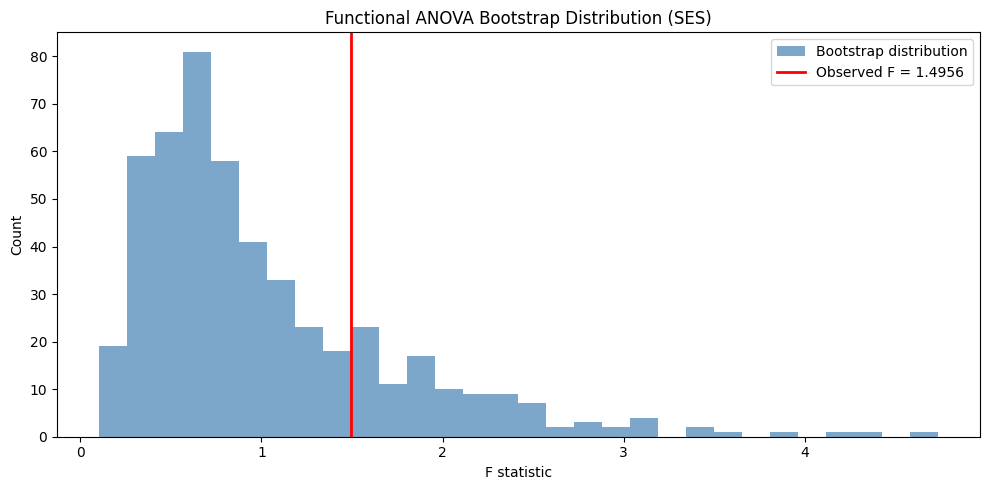

In [9]:
print('=== Functional one-way ANOVA (SES groups) ===')
anova_result = fanova_onefactor(
    groups=[Y_low, Y_mid, Y_high],
    t_seq=t_fine,
    n_boot=500,
    random_state=42
)
print(f'F statistic: {anova_result["statistic"]:.4f}')
print(f'p-value:     {anova_result["pvalue"]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(anova_result['boot_stats'], bins=30, color='steelblue', alpha=0.7,
        label='Bootstrap distribution')
ax.axvline(anova_result['statistic'], color='red', linewidth=2,
           label=f'Observed F = {anova_result["statistic"]:.4f}')
ax.set_xlabel('F statistic')
ax.set_ylabel('Count')
ax.set_title('Functional ANOVA Bootstrap Distribution (SES)')
ax.legend()
plt.tight_layout()
plt.show()


## Summary

In [10]:
sig_level = 0.05
print('=' * 40)
print('     HYPOTHESIS TESTING SUMMARY')
print('=' * 40)
print('H0: mu_Low(t) = mu_Mid(t) = mu_High(t)')
print('H1: at least one mean curve differs')
print(f'Low SES:  n = {len(low_idx)}  (Subjective SES 1-3)')
print(f'Mid SES:  n = {len(mid_idx)}  (Subjective SES 4-6)')
print(f'High SES: n = {len(high_idx)} (Subjective SES 7-9)')
print('1 subject excluded (NA SES)')
print('-' * 40)
print(f'Functional one-way ANOVA (500 bootstrap replications)')
print(f'{"F statistic:":<35}  {anova_result["statistic"]:.4f}')
print(f'{"p-value:":<35}  {anova_result["pvalue"]:.4f}')
print('-' * 40)
print(f'Significance level: alpha = {sig_level}')
if anova_result['pvalue'] > sig_level:
    print('Conclusion: FAIL TO REJECT H0.')
    print('No significant difference across SES groups.')
else:
    print('Conclusion: REJECT H0.')
    print('Significant difference across SES groups.')
print('=' * 40)


     HYPOTHESIS TESTING SUMMARY
H0: mu_Low(t) = mu_Mid(t) = mu_High(t)
H1: at least one mean curve differs
Low SES:  n = 17  (Subjective SES 1-3)
Mid SES:  n = 29  (Subjective SES 4-6)
High SES: n = 15 (Subjective SES 7-9)
1 subject excluded (NA SES)
----------------------------------------
Functional one-way ANOVA (500 bootstrap replications)
F statistic:                         1.4956
p-value:                             0.2080
----------------------------------------
Significance level: alpha = 0.05
Conclusion: FAIL TO REJECT H0.
No significant difference across SES groups.
